In [8]:
import pandas as pd
import numpy as np
# To train and test data
from sklearn.model_selection import train_test_split
# To manage categorical features
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
# To define the models
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
# To measure model quality
from sklearn.metrics import mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# Visualise
import matplotlib.pyplot as plt
# Save trained model
import pickle

In [9]:
# Load the data
path = '../data/csv/porsche_data.csv'
df = pd.read_csv(path)
## Drop rows with empty columns
df.dropna(inplace=True)
df

,id,model_year,model_type,mileage,condition,price_now,price_3_years_ago,appreciated,image_paths,seller_description,source
0,p00001,1987.0,944,132000.0,Fair,16250.0,13944,yes,"[""project/data/images/p00001_image_1.jpg"", ""pr...",project/data/descriptions/p00001_seller_descri...,https://bringatrailer.com/listing/1987-porsche...
1,p00002,1970.0,911,93000.0,Fair,84050.0,76500,yes,"[""project/data/images/p00002_image_1.jpg"", ""pr...",project/data/descriptions/p00002_seller_descri...,https://bringatrailer.com/listing/1970-porsche...
2,p00003,1970.0,911,2.0,Excellent,500000.0,73000,yes,"[""project/data/images/p00003_image_1.jpg"", ""pr...",project/data/descriptions/p00003_seller_descri...,https://bringatrailer.com/listing/1966-porsche...
3,p00004,2018.0,911,1200.0,Fair,435000.0,322000,yes,"[""project/data/images/p00004_image_1.jpg"", ""pr...",project/data/descriptions/p00004_seller_descri...,https://bringatrailer.com/listing/2018-porsche...
4,p00005,1965.0,356,148.0,Excellent,755000.0,4500,yes,"[""project/data/images/p00005_image_1.jpg"", ""pr...",project/data/descriptions/p00005_seller_descri...,https://bringatrailer.com/listing/1965-porsche...
...,...,...,...,...,...,...,...,...,...,...,...
1374,p01375,1976.0,911,59000.0,Fair,76000.0,35500,yes,"[""project/data/images/p01375_image_1.jpg"", ""pr...",project/data/descriptions/p01375_seller_descri...,https://bringatrailer.com/listing/1976-porsche...
1375,p01376,2023.0,Cayman,4600.0,Fair,186000.0,130000,yes,"[""project/data/images/p01376_image_1.jpg"", ""pr...",project/data/descriptions/p01376_seller_descri...,https://bringatrailer.com/listing/2023-porsche...
1376,p01377,1961.0,356,17000.0,Fair,148000.0,81000,yes,"[""project/data/images/p01377_image_1.jpg"", ""pr...",project/data/descriptions/p01377_seller_descri...,https://bringatrailer.com/listing/1961-porsche...
1377,p01378,1988.0,911,100000.0,Fair,80000.0,44750,yes,"[""project/data/images/p01378_image_1.jpg"", ""pr...",project/data/descriptions/p01378_seller_descri...,https://bringatrailer.com/listing/1988-porsche...


In [10]:
# Select data X and y
X_list = ['model_year', 'model_type', 'mileage', 'condition', 'price_now', 'price_3_years_ago']
X = df[X_list]
y = df.appreciated

# Label encode yes/no in col 'appreciated'
le = LabelEncoder()
y = le.fit_transform(y)

In [11]:
# Clean the data
## Manage categorical values - One-hot encoding
# read_csv often uses str dtype for text columns; dtype == 'object' misses those, so
# sklearn never saw OH columns and left raw values like 'Cayman' in X_oh.
CAT_COLS = ['model_type', 'condition']
oh = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = X[CAT_COLS].astype(str)
cols_oh = pd.DataFrame(
    oh.fit_transform(X_cat),
    columns=oh.get_feature_names_out(CAT_COLS),
    index=X.index,
)

## Numeric columns (coerce strings e.g. price_3_years_ago from CSV)
num_X = X.drop(columns=CAT_COLS).copy()
for _c in num_X.columns:
    num_X[_c] = pd.to_numeric(num_X[_c], errors='coerce')

## Combine categorical and numerical columns in X dataframes
X_oh = pd.concat([num_X, cols_oh], axis=1)

## Ensure all column names are strings
X_oh.columns = X_oh.columns.astype(str)

# Coercion can leave NaN (e.g. unparseable price_3_years_ago). LogisticRegression rejects NaN.
_row_ok = ~X_oh.isna().any(axis=1)
if not _row_ok.all():
    X_oh = X_oh.loc[_row_ok]
    y = np.asarray(y)[_row_ok.to_numpy()]

X_oh

,model_year,mileage,price_now,price_3_years_ago,model_type_356,model_type_911,model_type_912,model_type_914,model_type_918,model_type_924,...,model_type_958,model_type_959,model_type_962,model_type_964,model_type_968,model_type_991,model_type_Boxster,model_type_Cayman,condition_Excellent,condition_Fair
0,1987.0,132000.0,16250.0,13944.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1970.0,93000.0,84050.0,76500.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1970.0,2.0,500000.0,73000.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2018.0,1200.0,435000.0,322000.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1965.0,148.0,755000.0,4500.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1374,1976.0,59000.0,76000.0,35500.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1375,2023.0,4600.0,186000.0,130000.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1376,1961.0,17000.0,148000.0,81000.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1377,1988.0,100000.0,80000.0,44750.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [12]:
# Train
train_X, val_X, train_y, val_y = train_test_split(X_oh, y, random_state=0)
train_X

,model_year,mileage,price_now,price_3_years_ago,model_type_356,model_type_911,model_type_912,model_type_914,model_type_918,model_type_924,...,model_type_958,model_type_959,model_type_962,model_type_964,model_type_968,model_type_991,model_type_Boxster,model_type_Cayman,condition_Excellent,condition_Fair
365,2023.0,17000.0,148000.0,128000.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
197,1991.0,82000.0,128964.0,142000.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1337,2018.0,174.0,560000.0,239000.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
722,1998.0,59000.0,146000.0,135000.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
748,1976.0,75000.0,30250.0,34424.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
854,1983.0,75000.0,68500.0,75500.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
934,2024.0,4700.0,97000.0,130000.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1363,2000.0,36000.0,47500.0,39000.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
617,2003.0,97000.0,47000.0,28000.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [13]:
# Choose best max number of leaf nodes in Random Forest
def get_mae(train_X, val_X, train_y, val_y, model):
    model.fit(train_X, train_y)
    preds = model.predict(val_X)
    mae = mean_absolute_error(val_y, preds)
    return mae

model1 = RandomForestRegressor()
print('Random Forest')
for max_nodes in [5, 50, 500, 5000, 50000]:
    nodes_mae1 = get_mae(train_X, val_X, train_y, val_y, model=model1)
    print(f'Max leaf nodes: {max_nodes}\t\tMAE: {nodes_mae1}')

Random Forest
Max leaf nodes: 5		MAE: 0.1041883116883117
Max leaf nodes: 50		MAE: 0.10551948051948051
Max leaf nodes: 500		MAE: 0.10159090909090909
Max leaf nodes: 5000		MAE: 0.10623376623376624
Max leaf nodes: 50000		MAE: 0.10357142857142858


In [14]:
# Random Forest: Define and fit the model
model1 = RandomForestRegressor(max_leaf_nodes=500)
model1.fit(train_X, train_y)

# Inference
preds1 = model1.predict(val_X)

print(f'Random Forest accuracy: {round(model1.score(val_X, val_y)*100, 2)}%')

Random Forest accuracy: 82.98%


In [15]:
# Logistic Regression: Define and fit the model
model2 = LogisticRegression(max_iter=10000)
model2.fit(train_X, train_y)

# Inference
preds2 = model2.predict(val_X)

print(f'Logistic Regression accuracy: {round(model2.score(val_X, val_y)*100, 2)}%')

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [10]:
# Evaluate model1 and model2
for name, model in [('Random Forest', model1), ('Logistic Regression', model2)]:
    pred_y = model.predict(val_X)
    # Convert inference/prediction made by Random Forest model to readable output
    if model == model1:
        pred_y = np.round(pred_y).astype(int)
    print(f'\n{name}\
            \n\tAccuracy: {round(accuracy_score(val_y, pred_y), 2)*100}%\
            \n\tPrecision: {round(precision_score(val_y, pred_y), 2)*100}%\
            \n\tRecall: {round(recall_score(val_y, pred_y), 2)*100}%\
            \n\tF1-score: {round(f1_score(val_y, pred_y), 2)*100}%')

print('\nThe best model is using the Random Forest Regressor.')


Random Forest            
	Accuracy: 81.0%            
	Precision: 78.0%            
	Recall: 83.0%            
	F1-score: 81.0%

Logistic Regression            
	Accuracy: 62.0%            
	Precision: 59.0%            
	Recall: 71.0%            
	F1-score: 64.0%

The best model is using the Random Forest Regressor.


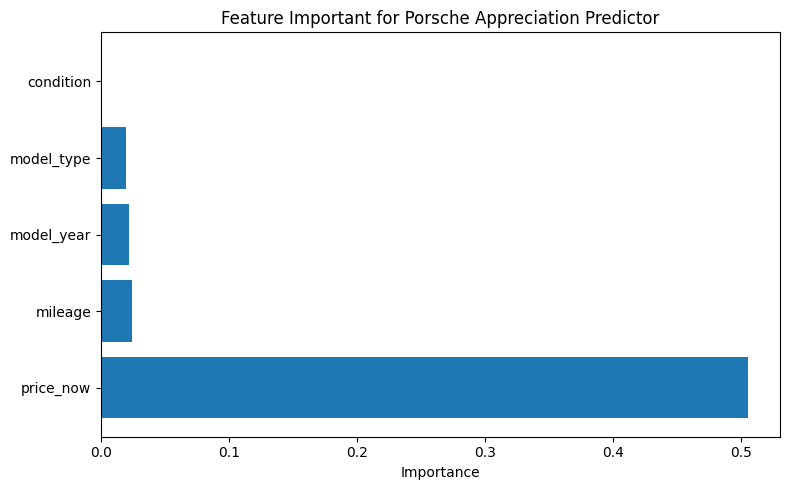

In [16]:
# Random Forest: Feature importance
importances = model1.feature_importances_
feature_names = train_X.columns.tolist()

# OH columns use sklearn names (e.g. model_type_Cayman); aggregate by prefix
desired_features = ['price_now', 'mileage', 'model_year', 'model_type']
filtered_importances = []
filtered_names = []

for feature in desired_features:
    if feature in feature_names:
        idx = feature_names.index(feature)
        filtered_importances.append(importances[idx])
        filtered_names.append(feature)

model_type_importance = 0.0
condition_importance = 0.0
for i, name in enumerate(feature_names):
    n = str(name)
    if n.startswith('model_type_'):
        model_type_importance += importances[i]
    elif n.startswith('condition_'):
        condition_importance += importances[i]

filtered_importances.append(model_type_importance)
filtered_names.append('model_type')
filtered_importances.append(condition_importance)
filtered_names.append('condition')

plt.figure(figsize=(8,5))
plt.barh(filtered_names, filtered_importances)
plt.xlabel('Importance')
plt.title('Feature Important for Porsche Appreciation Predictor')
plt.tight_layout()
# plt.savefig('feature_importance.jpg', dpi=300)
plt.show()

In [12]:
# Save trained model
import os; os.makedirs('../data', exist_ok=True)
pickle.dump(model1, open('../data/porsche_model.pkl', 'wb'))
# Save OH encoder
pickle.dump(oh, open('../data/porsche_encoder.pkl', 'wb'))

# Model Performance
The **Random Forest** model achieved **78%** accuracy on the validation set, outperforming Logistic Regression (62% accuracy). The Random Forest model also showed strong performance across other metrics: **75%** precision, **83%** recall, and **79%** F1-score, indicating good balance between identifying appreciating Porsches and avoiding false positives.

# Feature Importance Analysis
Feature importance analysis revealed that **price_now** is the strongest predictor of Porsche appreciation, with an importance score of approximately **0.30**. This suggests that **current market price** is a key indicator of whether a vehicle will appreciate.

**Model year** and **mileage** follow with similar importance scores (**~0.13** and **~0.12**, respectively), indicating that both the **age** and **usage history** of the vehicle play meaningful roles in appreciation prediction.

The categorical features model_type and condition also contribute to the model's predictions, though their aggregated importance is lower than the numerical features.